In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

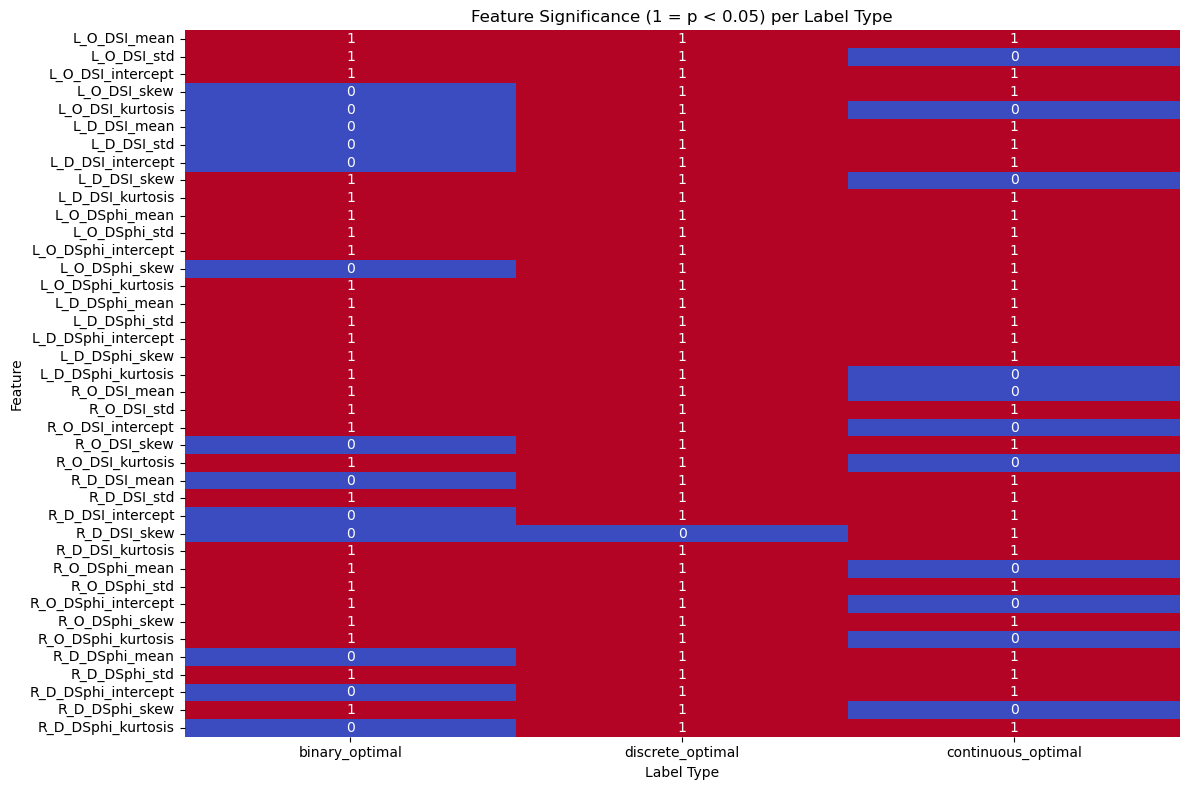

In [15]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis, linregress, mannwhitneyu, kruskal, spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv("/Users/juliasantaniello/Desktop/NeuroLoop-Classification/fNIRS/024_RP_LabeledData.csv")
df2 = pd.read_csv("/Users/juliasantaniello/Desktop/NeuroLoop-Classification/fNIRS/010_RP_LabeledData.csv")
df3 = pd.read_csv("/Users/juliasantaniello/Desktop/NeuroLoop-Classification/fNIRS/015_RP_LabeledData.csv")

df = pd.concat([df, df2, df3], ignore_index=True)
# Channels to process
fnirs_channels = [
    'L_O_DSI', 'L_D_DSI', 'L_O_DSphi', 'L_D_DSphi',
    'R_O_DSI', 'R_D_DSI', 'R_O_DSphi', 'R_D_DSphi'
]

# Labels to analyze
label_columns = ['binary_optimal', 'discrete_optimal', 'continuous_optimal']

# Parameters
window_size = 45  # in rows/samples; adjust based on sampling rate
step_size = 1

# Feature functions
def compute_features(segment):
    features = []
    x = np.arange(len(segment))
    for ch_data in segment.T:
        slope, intercept, *_ = linregress(x, ch_data)
        features.extend([
            np.mean(ch_data),
            np.std(ch_data),
            intercept,
            skew(ch_data),
            kurtosis(ch_data)
        ])
    return features

# Sliding window feature matrix
feature_names = ['mean', 'std', 'intercept', 'skew', 'kurtosis']
combined_features = []
labels_at_endpoint = {col: [] for col in label_columns}

for start in range(0, len(df) - window_size, step_size):
    end = start + window_size
    segment = df[fnirs_channels].iloc[start:end].values
    feats = compute_features(segment)
    combined_features.append(feats)
    
    for col in label_columns:
        labels_at_endpoint[col].append(df[col].iloc[end - 1])

# Create DataFrame of features
all_features = pd.DataFrame(combined_features)
# Label columns: feature_0, feature_1, ..., feature_N
feature_labels = [
    f"{ch}_{feat}"
    for ch in fnirs_channels
    for feat in feature_names
]
all_features.columns = feature_labels

# Add endpoint-aligned labels
for col in label_columns:
    all_features[col] = labels_at_endpoint[col]

# Significance testing
significance_matrix = pd.DataFrame(index=feature_labels, columns=label_columns)

for label in label_columns:
    for feature in feature_labels:
        x = all_features[feature]
        y = all_features[label]
        
        if label == 'binary_optimal':
            group0 = x[y == 0]
            group1 = x[y == 1]
            if len(group0) > 1 and len(group1) > 1:
                _, p = mannwhitneyu(group0, group1, alternative='two-sided')
            else:
                p = np.nan
        
        elif label == 'discrete_optimal':
            groups = [x[y == val] for val in sorted(y.dropna().unique())]
            if all(len(g) > 1 for g in groups):
                _, p = kruskal(*groups)
            else:
                p = np.nan
        
        elif label == 'continuous_optimal':
            if y.isnull().any():
                p = np.nan
            else:
                _, p = spearmanr(x, y)
        
        significance_matrix.loc[feature, label] = p

# Mark significance
sig_binary = significance_matrix.astype(float) < 0.05

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(sig_binary.astype(int), annot=True, fmt="d", cmap="coolwarm", cbar=False)
plt.title("Feature Significance (1 = p < 0.05) per Label Type")
plt.xlabel("Label Type")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


5
10
20
30
40


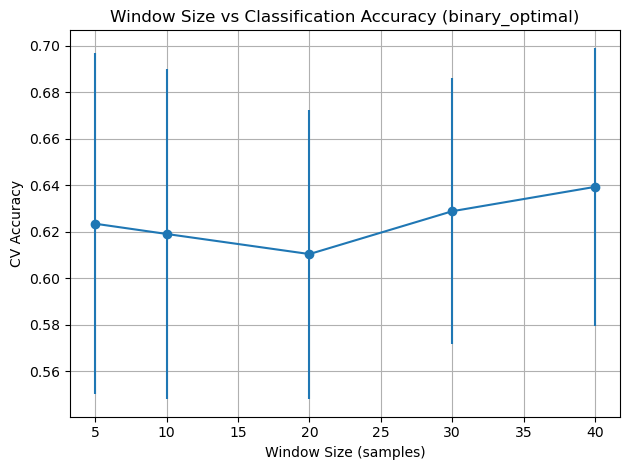


🏆 Best window size: 40.0 samples with accuracy: 0.639


In [16]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis, linregress
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Load your data
# df = pd.read_csv("/Users/juliasantaniello/Desktop/NeuroLoop-Classification/fNIRS/024_RP_LabeledData.csv")

# Parameters
fnirs_channels = [
    'L_O_DSI', 'L_D_DSI', 'L_O_DSphi', 'L_D_DSphi',
    'R_O_DSI', 'R_D_DSI', 'R_O_DSphi', 'R_D_DSphi'
]
label_col = 'binary_optimal'  # Change to desired label
feature_names = ['mean', 'std', 'intercept', 'skew', 'kurtosis']
window_sizes = [5, 10, 20, 30, 40]  # in samples (adjust if sampling rate ≠ 1 Hz)
step_size = 1  # sliding step in samples

# Feature extraction function
def compute_features(segment):
    features = []
    x = np.arange(len(segment))
    for ch_data in segment.T:
        slope, intercept, *_ = linregress(x, ch_data)
        features.extend([
            np.mean(ch_data),
            np.std(ch_data),
            intercept,
            skew(ch_data),
            kurtosis(ch_data)
        ])
    return features

# Evaluation storage
window_results = []

for window_size in window_sizes:
    print(window_size)
    feature_vecs = []
    labels = []

    for start in range(0, len(df) - window_size, step_size):
        end = start + window_size
        segment = df[fnirs_channels].iloc[start:end].values
        label = df[label_col].iloc[end - 1]
        if pd.isna(label):
            continue
        features = compute_features(segment)
        feature_vecs.append(features)
        labels.append(label)

    X = np.array(feature_vecs)
    y = np.array(labels)

    # Basic model (use RandomForest here; you could also test SVM or MLP)
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')

    window_results.append({
        'window_size': window_size,
        'mean_score': np.mean(scores),
        'std_score': np.std(scores)
    })

# Plotting
results_df = pd.DataFrame(window_results)

plt.errorbar(results_df['window_size'], results_df['mean_score'],
             yerr=results_df['std_score'], fmt='-o')
plt.title(f"Window Size vs Classification Accuracy ({label_col})")
plt.xlabel("Window Size (samples)")
plt.ylabel("CV Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

# Print best window size
best_row = results_df.loc[results_df['mean_score'].idxmax()]
print(f"\n Best window size: {best_row['window_size']} samples with accuracy: {best_row['mean_score']:.3f}")
